# MSCS 634 Project Deliverable 2
## Regression Modeling and Performance Evaluation

**Dataset:** Online Shoppers Purchasing Intention Dataset [UCI Machine Learning Repository]

**Group Members:**

Arun Gyawali

Kashif Ali Syed

Jiwon Jung

Hanuman Sai Chanukya Srinivas Chilamkuri

**Course:** MSCS 634

## Introduction

This deliverable builds on the cleaned Online Shoppers Purchasing Intention dataset produced in Deliverable 1 (`online_shoppers_cleaned.csv`, 12,205 sessions and 18 columns). The goal of this phase is to move from exploration to prediction by engineering new features, building multiple regression models, and evaluating and comparing their performance using standard regression metrics and cross-validation.

**Tasks completed in this notebook:**

- Perform feature engineering to create new, informative predictors
- Build at least two regression models (Linear Regression, Ridge Regression, and Lasso Regression, plus a Random Forest Regressor for comparison)
- Evaluate each model using R-squared, Mean Squared Error (MSE), and Root Mean Squared Error (RMSE)
- Apply k-fold cross-validation to assess generalization to unseen data
- Compare model performance and summarize the insights gained

## Selecting a Regression Target

The dataset's primary target variable, `Revenue`, is Boolean and is reserved for the classification task in Deliverable 3. For this regression deliverable, a **continuous** target is required.

Two candidates were considered:

- **PageValues** — the average value of the pages visited before a purchase. Deliverable 1 showed this had the strongest correlation with Revenue (~0.49). However, further inspection shows that PageValues is **zero for about 77.6% of sessions**, which makes it extremely zero-inflated and very difficult for standard regression models to fit well.
- **ProductRelated_Duration** — the total time (in seconds) a visitor spends on product-related pages during a session. Only about 5% of sessions have a value of zero, so it behaves much more like a genuine continuous variable, and it is still directly tied to customer engagement and purchasing intent (Deliverable 1 found it was higher for purchasing sessions: 1,797.8s vs. 1,047.3s).

Because of this, **ProductRelated_Duration** was selected as the regression target. It represents how long a visitor engages with product content during a session, which is a practical, business-relevant quantity to predict (for example, to flag sessions that are likely to have low engagement in real time).

In [1]:
# Import required libraries for Deliverable 2

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Modeling
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42

## Dataset Loading

The cleaned dataset produced in Deliverable 1 is loaded directly, so all the cleaning and outlier-capping steps from that phase are already reflected here.

In [2]:
# Load the cleaned dataset produced in Deliverable 1
data = pd.read_csv("online_shoppers_cleaned.csv")
df = data.copy()

print("Shape:", df.shape)
df.head()

Shape: (12205, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  str    
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType              12205 no

## Feature Engineering

New features were created to capture behavioral patterns that were not directly available in the original dataset. None of the engineered features were created using `ProductRelated_Duration`, which is the regression target, so target leakage was avoided.

The engineered features are:

- **Total_Pages** — total number of Administrative, Informational, and ProductRelated pages visited during a session.
- **NonProduct_Duration** — total time spent on Administrative and Informational pages.
- **Avg_NonProduct_Duration_Per_Page** — average time spent on each non-product page.
- **BounceExitRatio** — ratio of BounceRates to ExitRates.
- **Engagement_Score** — ProductRelated page count multiplied by PageValues.

`Month`, `VisitorType`, `OperatingSystems`, `Browser`, `Region`, and `TrafficType` were one-hot encoded. Although OperatingSystems, Browser, Region, and TrafficType were stored as numbers, they represent category codes rather than continuous measurements.

`Weekend` and `Revenue` were converted into integer values. Revenue was later excluded from the regression predictors because it will be used as the classification target in Deliverable 3.

In [3]:
# Engineered features (independent of the ProductRelated_Duration target)
df['Total_Pages'] = df['Administrative'] + df['Informational'] + df['ProductRelated']

df['NonProduct_Duration'] = df['Administrative_Duration'] + df['Informational_Duration']

nonproduct_pages = (df['Administrative'] + df['Informational']).replace(0, np.nan)
df['Avg_NonProduct_Duration_Per_Page'] = (df['NonProduct_Duration'] / nonproduct_pages).fillna(0)

df['BounceExitRatio'] = df['BounceRates'] / (df['ExitRates'] + 0.001)

df['Engagement_Score'] = df['ProductRelated'] * df['PageValues']

# Convert Boolean columns into integers.
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

# These variables represent categories, even when
# their values are stored as numbers.
categorical_features = [
    "Month",
    "VisitorType",
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]

# Convert coded category columns to strings before encoding.
for column in [
    "OperatingSystems",
    "Browser",
    "Region",
    "TrafficType"
]:
    df[column] = df[column].astype(str)

# One-hot encode all categorical variables.
df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)
df[['Total_Pages', 'NonProduct_Duration', 'Avg_NonProduct_Duration_Per_Page',
    'BounceExitRatio', 'Engagement_Score']].describe()

,Total_Pages,NonProduct_Duration,Avg_NonProduct_Duration_Per_Page,BounceExitRatio,Engagement_Score
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,34.893240,107.713995,22.981771,0.275324,235.740726
std,46.627336,196.983345,44.351356,0.334693,980.891249
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000000,0.000000,0.000000,0.000000,0.000000
50%,20.000000,20.000000,9.000000,0.154044,0.000000
75%,42.000000,123.000000,29.300000,0.487805,0.000000
max,746.000000,1560.665614,838.421582,3.626220,36393.409166


### Correlation of Engineered Features with the Target

Before modeling, it is useful to check how the new features relate to `ProductRelated_Duration`.

In [4]:
engineered_features = ['Total_Pages', 'NonProduct_Duration', 'Avg_NonProduct_Duration_Per_Page',
                       'BounceExitRatio', 'Engagement_Score']

correlations = df[engineered_features + ['ProductRelated_Duration']].corr()['ProductRelated_Duration'].drop('ProductRelated_Duration')
correlations.sort_values(ascending=False)

Total_Pages                         0.846764
NonProduct_Duration                 0.398873
Engagement_Score                    0.237997
Avg_NonProduct_Duration_Per_Page    0.182804
BounceExitRatio                    -0.046738
Name: ProductRelated_Duration, dtype: float64

### Engineered Feature Correlation Insights

`Total_Pages` had the strongest correlation with `ProductRelated_Duration` at approximately 0.847. This indicates that sessions containing more page visits generally accumulated more product-related browsing time.

`NonProduct_Duration` had a moderate positive correlation of approximately 0.399, while `Engagement_Score` had a correlation of approximately 0.238. `Avg_NonProduct_Duration_Per_Page` had a smaller positive correlation of approximately 0.183.

`BounceExitRatio` had a weak negative correlation of approximately -0.047. This suggests that the ratio provides limited direct linear information about product-related duration, although it may still contribute to a non-linear model when combined with other features.

## Defining Features and Target

`ProductRelated_Duration` was selected as the continuous regression target.

`Revenue` was excluded from the predictor set because it will be used as the classification target in Deliverable 3. Excluding it also prevents the regression model from using the final purchasing outcome to predict browsing duration.

Redundant component variables were removed before modeling. `Administrative` and `Informational` were removed because their information was represented within `Total_Pages`. `Administrative_Duration` and `Informational_Duration` were removed because their combined information was represented by `NonProduct_Duration`.

After feature engineering, categorical encoding, and redundant-feature removal, the final predictor matrix contained 68 features for 12,205 sessions.

In [6]:
# Select the continuous regression target.
target = "ProductRelated_Duration"

# Remove the target, Revenue, and redundant component features.
# Total_Pages already represents the three page-count columns.
# NonProduct_Duration already represents the two non-product
# duration columns.
columns_to_remove = [
    target,
    "Revenue",
    "Administrative",
    "Informational",
    "Administrative_Duration",
    "Informational_Duration"
]

# Create the predictor matrix and target variable.
X = df.drop(columns=columns_to_remove)
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

X.columns.tolist()

Feature matrix shape: (12205, 68)
Target shape: (12205,)


['ProductRelated',
 'BounceRates',
 'ExitRates',
 'PageValues',
 'SpecialDay',
 'Weekend',
 'Total_Pages',
 'NonProduct_Duration',
 'Avg_NonProduct_Duration_Per_Page',
 'BounceExitRatio',
 'Engagement_Score',
 'Month_Dec',
 'Month_Feb',
 'Month_Jul',
 'Month_June',
 'Month_Mar',
 'Month_May',
 'Month_Nov',
 'Month_Oct',
 'Month_Sep',
 'VisitorType_Other',
 'VisitorType_Returning_Visitor',
 'OperatingSystems_2',
 'OperatingSystems_3',
 'OperatingSystems_4',
 'OperatingSystems_5',
 'OperatingSystems_6',
 'OperatingSystems_7',
 'OperatingSystems_8',
 'Browser_10',
 'Browser_11',
 'Browser_12',
 'Browser_13',
 'Browser_2',
 'Browser_3',
 'Browser_4',
 'Browser_5',
 'Browser_6',
 'Browser_7',
 'Browser_8',
 'Browser_9',
 'Region_2',
 'Region_3',
 'Region_4',
 'Region_5',
 'Region_6',
 'Region_7',
 'Region_8',
 'Region_9',
 'TrafficType_10',
 'TrafficType_11',
 'TrafficType_12',
 'TrafficType_13',
 'TrafficType_14',
 'TrafficType_15',
 'TrafficType_16',
 'TrafficType_17',
 'TrafficType_18',


## Train-Test Split and Feature Scaling

The data was divided into an 80% training set and a 20% test set using a random state of 42. This produced 9,764 training observations and 2,441 test observations, with 68 predictor features.

For held-out test evaluation, `StandardScaler` was fitted only on the training data and then applied to the test data. This prevented information from the test set from influencing the scaling process.

During cross-validation, scaling was performed inside a pipeline so that the scaler was fitted separately within every training fold. This prevented preprocessing leakage between the training and validation folds.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set:", X_train_scaled.shape)
print("Test set:", X_test_scaled.shape)

Training set: (9764, 68)
Test set: (2441, 68)


## Model Building and Evaluation

Four regression models were developed and compared:

1. **Linear Regression** — used as the baseline regression model.
2. **Ridge Regression** — applied L2 regularization to reduce the influence of correlated predictors.
3. **Lasso Regression** — applied L1 regularization and could reduce the coefficients of less useful features.
4. **Random Forest Regressor** — used as a non-linear benchmark to determine whether more complex relationships existed in the data.

Each model was evaluated on the held-out test set using R-squared, Mean Squared Error, and Root Mean Squared Error.

In [8]:
results = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)

    results[name] = {'model': model, 'R2': r2, 'MSE': mse, 'RMSE': rmse}
    print(f"{name}:  R2 = {r2:.4f}   MSE = {mse:,.2f}   RMSE = {rmse:,.2f}")
    return model

### Model 1: Linear Regression

In [9]:
linear_model = evaluate_model(
    "Linear Regression", LinearRegression(),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Linear Regression:  R2 = 0.7188   MSE = 692,990.14   RMSE = 832.46


### Model 2: Ridge Regression

In [10]:
ridge_model = evaluate_model(
    "Ridge Regression", Ridge(alpha=1.0, random_state=RANDOM_STATE),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Ridge Regression:  R2 = 0.7188   MSE = 693,176.22   RMSE = 832.57


### Model 3: Lasso Regression

In [11]:
lasso_model = evaluate_model(
    "Lasso Regression", Lasso(alpha=1.0, max_iter=10000, random_state=RANDOM_STATE),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Lasso Regression:  R2 = 0.7190   MSE = 692,592.87   RMSE = 832.22


### Model 4: Random Forest Regressor (Benchmark)

A tree-based ensemble model is included to test whether a non-linear model can capture patterns that the linear models miss.

In [12]:
rf_model = evaluate_model(
    "Random Forest", RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
    X_train_scaled, X_test_scaled, y_train, y_test
)

Random Forest:  R2 = 0.7506   MSE = 614,684.76   RMSE = 784.02


## Cross-Validation

Five-fold cross-validation was applied to the training data to evaluate how consistently each model generalized across different subsets of the data.

The folds were shuffled using a random state of 42. Linear Regression, Ridge Regression, and Lasso Regression were placed inside pipelines so that `StandardScaler` was fitted separately within each fold. Random Forest was evaluated directly because tree-based models do not require feature scaling.

Mean R-squared and RMSE values were calculated across the five folds, along with their standard deviations.

In [13]:
# Create five shuffled folds for cross-validation.
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Create pipelines so scaling is performed separately
# inside every cross-validation fold.
models_for_cv = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            Lasso(
                alpha=1.0,
                max_iter=10000,
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

# Store the cross-validation results.
cv_results = {}

for name, model in models_for_cv.items():

    # Calculate R-squared across the five folds.
    r2_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring="r2"
    )

    # Calculate RMSE across the five folds.
    rmse_scores = -cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring="neg_root_mean_squared_error"
    )

    # Store the mean and standard deviation.
    cv_results[name] = {
        "CV_R2_mean": r2_scores.mean(),
        "CV_R2_std": r2_scores.std(),
        "CV_RMSE_mean": rmse_scores.mean(),
        "CV_RMSE_std": rmse_scores.std()
    }

    print(
        f"{name}: "
        f"CV R2 = {r2_scores.mean():.4f} "
        f"(+/- {r2_scores.std():.4f}), "
        f"CV RMSE = {rmse_scores.mean():,.2f} "
        f"(+/- {rmse_scores.std():,.2f})"
    )

Linear Regression: CV R2 = 0.7318 (+/- 0.0133), CV RMSE = 803.28 (+/- 40.91)
Ridge Regression: CV R2 = 0.7318 (+/- 0.0133), CV RMSE = 803.28 (+/- 40.92)
Lasso Regression: CV R2 = 0.7321 (+/- 0.0136), CV RMSE = 802.96 (+/- 41.23)
Random Forest: CV R2 = 0.7702 (+/- 0.0142), CV RMSE = 742.97 (+/- 28.93)


## Model Comparison

The test-set metrics and cross-validation results are combined into a single comparison table.

In [14]:
comparison = pd.DataFrame({
    name: {
        'Test R2': results[name]['R2'],
        'Test MSE': results[name]['MSE'],
        'Test RMSE': results[name]['RMSE'],
        'CV R2 (mean)': cv_results[name]['CV_R2_mean'],
        'CV RMSE (mean)': cv_results[name]['CV_RMSE_mean']
    }
    for name in results
}).T

comparison.sort_values('CV R2 (mean)', ascending=False)

,Test R2,Test MSE,Test RMSE,CV R2 (mean),CV RMSE (mean)
Random Forest,0.750614,614684.764485,784.018344,0.770210,742.971876
Lasso Regression,0.719005,692592.873557,832.221649,0.732058,802.958631
Ridge Regression,0.718769,693176.217273,832.572049,0.731846,803.279987
Linear Regression,0.718844,692990.137606,832.460292,0.731846,803.282008


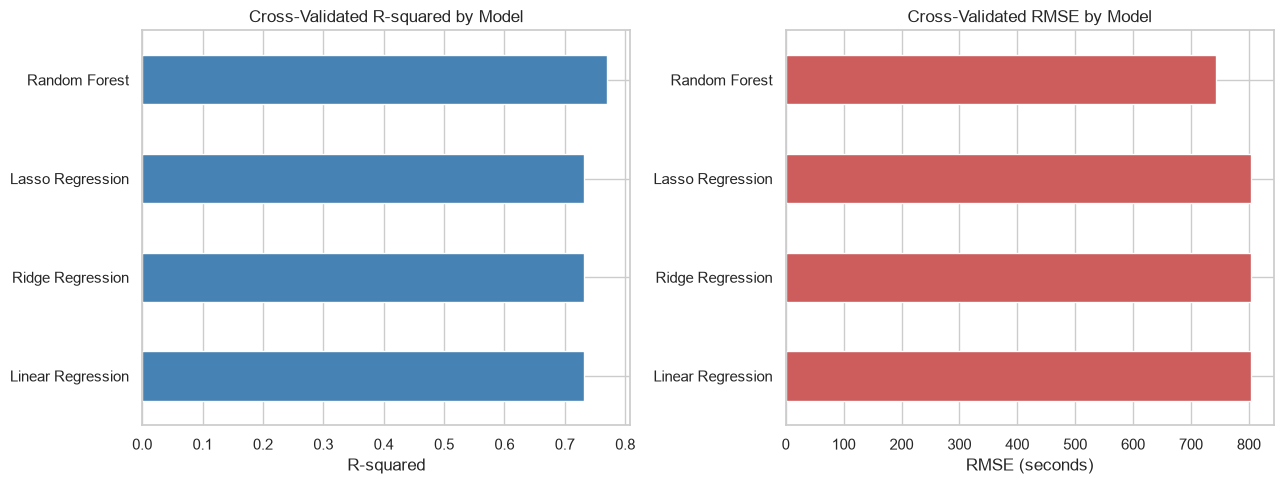

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparison['CV R2 (mean)'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Cross-Validated R-squared by Model')
axes[0].set_xlabel('R-squared')

comparison['CV RMSE (mean)'].sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title('Cross-Validated RMSE by Model')
axes[1].set_xlabel('RMSE (seconds)')

plt.tight_layout()
plt.show()

### Predicted vs. Actual Values (Best Model)

A scatterplot of predicted versus actual values for the best-performing model gives a visual sense of model fit. Points close to the diagonal line indicate accurate predictions.

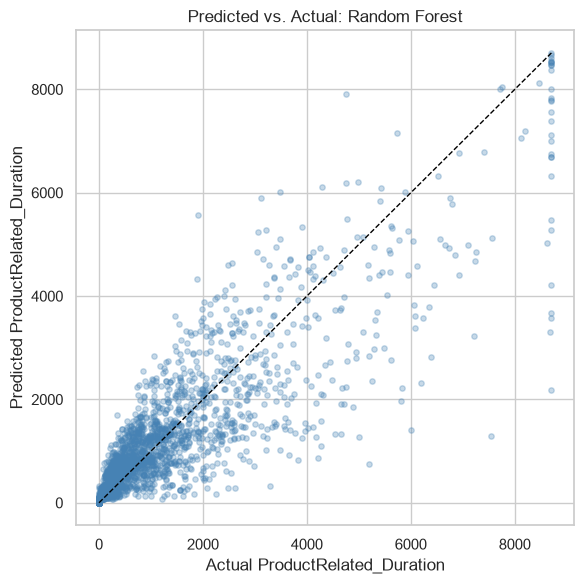

Best model based on cross-validated R-squared: Random Forest


In [16]:
best_model_name = comparison['CV R2 (mean)'].idxmax()
best_model = results[best_model_name]['model']

y_pred_best = best_model.predict(X_test_scaled)

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, s=15, color='steelblue')
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=1)
plt.xlabel('Actual ProductRelated_Duration')
plt.ylabel('Predicted ProductRelated_Duration')
plt.title(f'Predicted vs. Actual: {best_model_name}')
plt.tight_layout()
plt.show()

print(f"Best model based on cross-validated R-squared: {best_model_name}")

### Predicted Versus Actual Insight

The Random Forest model was selected as the best-performing model based on cross-validated R-squared.

The predicted values generally followed the diagonal reference line, especially for sessions with lower and moderate product-related durations. However, the predictions became more dispersed as the actual duration increased. Some extremely long sessions were underpredicted, showing that the model was less precise for unusually high engagement values.

The test R-squared of 0.7506 indicates that the model explained approximately 75.06% of the variation in ProductRelated_Duration. Its test RMSE of 784.02 seconds shows that noticeable prediction error remained, particularly among the longest sessions.

### Feature Importance

For the Random Forest model, feature importances show which variables were most useful in predicting product-page engagement time. For the linear models, the magnitude of the standardized coefficients serves the same purpose.

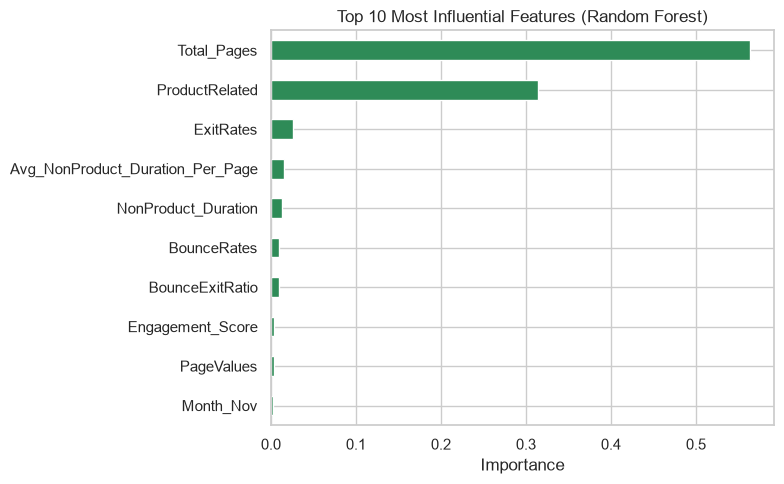

Total_Pages                         0.563670
ProductRelated                      0.314521
ExitRates                           0.025581
Avg_NonProduct_Duration_Per_Page    0.015920
NonProduct_Duration                 0.012677
BounceRates                         0.009923
BounceExitRatio                     0.009330
Engagement_Score                    0.004090
PageValues                          0.004024
Month_Nov                           0.002970
dtype: float64

In [17]:
if best_model_name == "Random Forest":
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top_features = importances.sort_values(ascending=False).head(10)
else:
    coefs = pd.Series(best_model.coef_, index=X.columns)
    top_features = coefs.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top_features.sort_values().plot(kind='barh', color='seagreen')
plt.title(f'Top 10 Most Influential Features ({best_model_name})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

top_features

### Feature Importance Insights

`Total_Pages` was the most influential Random Forest feature, with an importance of approximately 0.564. `ProductRelated` page count was the second-most influential feature at approximately 0.315. Together, these two variables accounted for most of the model's predictive importance.

`ExitRates` had an importance of approximately 0.026. The engineered features `Avg_NonProduct_Duration_Per_Page` and `NonProduct_Duration` had importances of approximately 0.016 and 0.013.

`BounceRates` and `BounceExitRatio` made smaller contributions of approximately 0.010 and 0.009. `Engagement_Score`, `PageValues`, and the November indicator contributed less than 0.005 individually.

These results show that overall browsing depth and the number of product pages visited were the main predictors of product-related browsing duration. Feature importance reflects the Random Forest model's use of each variable and does not establish a causal relationship.

## Summary of Results and Insights

### Model Performance

The three linear models produced very similar results. Linear Regression achieved a test R-squared of 0.7188 and an RMSE of 832.46 seconds. Ridge Regression achieved a test R-squared of 0.7188 and an RMSE of 832.57 seconds. Lasso Regression performed slightly better, with a test R-squared of 0.7190 and an RMSE of 832.22 seconds.

The similarity among the linear models shows that Ridge and Lasso regularization did not materially improve predictive performance with the selected settings. This does not mean correlated predictors were absent. Redundant feature relationships were reviewed and removed before final modeling.

The Random Forest Regressor produced the best test-set performance, with an R-squared of 0.7506, MSE of 614,684.76, and RMSE of 784.02 seconds.

Cross-validation produced similar conclusions. Linear Regression and Ridge Regression both achieved a mean cross-validated R-squared of approximately 0.7318. Lasso Regression achieved approximately 0.7321. Random Forest achieved the highest mean cross-validated R-squared at 0.7702 and the lowest mean cross-validated RMSE at 742.97 seconds.

The similarity between the held-out test results and cross-validation results indicates that the models generalized reasonably well.

### Feature Engineering Insights

`Total_Pages` had the strongest engineered-feature correlation with the target at approximately 0.847. It was also the most influential Random Forest feature, with an importance of approximately 0.564.

`ProductRelated` page count was the second-most important feature, with an importance of approximately 0.315. These findings show that visitors who browse more pages, especially product pages, generally accumulate more product-related browsing time.

`Avg_NonProduct_Duration_Per_Page`, `NonProduct_Duration`, and `BounceExitRatio` provided smaller amounts of predictive information. `Engagement_Score` was not among the strongest predictors, so its individual contribution appeared limited in the final model.

### Target Selection

`PageValues` was originally considered as the regression target but was zero for approximately 77.6% of sessions. This made it highly zero-inflated and unsuitable for the standard regression approach used in this deliverable.

`ProductRelated_Duration` was selected because it behaved more like a continuous target and represented a practical measure of customer engagement.

### Overall Conclusion

Random Forest outperformed the three linear models, suggesting that the relationship between browsing behavior and product-related duration contains non-linear patterns.

The model results also suggest that tree-based or other non-linear models may be useful during Deliverable 3 when Revenue is modeled as a classification target.

## Challenges Encountered

- **Selecting an appropriate regression target:** `PageValues` was originally considered but was zero for approximately 77.6% of sessions. `ProductRelated_Duration` was selected instead because it behaved more like a continuous variable.

- **Avoiding target leakage:** Engineered features were designed without using `ProductRelated_Duration`. Revenue was also excluded because it represents the final purchase outcome and will be used as the classification target in Deliverable 3.

- **Handling categorical codes:** `OperatingSystems`, `Browser`, `Region`, and `TrafficType` were stored as numbers but represented categories. They were converted to strings and one-hot encoded instead of being treated as continuous numerical variables.

- **Reducing redundant feature relationships:** The original component variables used to create `Total_Pages` and `NonProduct_Duration` were removed from the final predictor matrix. This reduced exact redundancy and made the linear-model analysis more reliable.

- **Preventing cross-validation leakage:** Scaling was placed inside model pipelines so that `StandardScaler` was fitted independently within each cross-validation fold.

- **Lasso convergence:** The default iteration limit was insufficient for Lasso Regression. Increasing `max_iter` to 10,000 resolved the convergence issue.